# An Overview of the current literature in Video to Video Summarization

The goal of video summarization is to create a short summary from the original video. The idea behind designing modelling strategy is to predict how relevant different parts of the videos are.

The method through which the current literature attempts to achieve this is by developing strategies which predicts frame-wise ``Importance" scores, and comparing the ground truth. The videos are pre-processed to detect the shots of the video. The predictions of the model are post-processed to predict the video Summary.

In this notebook, we examine each of these steps. Visualizing the steps at each step and illustrating the various challenges in the process. 


## Imports 

In [2]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from Utils import load_tvsum_mat, generate_summary_single

## How are the dataset annotated

Video Summarization annotation is a bit tricky, as its evaluation is a bit difficult. Currently, the approach to annotate video summarization has one of two strategies:

1. Ask annotators to label parts of the video included in their Summary (as a 0/1 vector)
2. Ask annotators to rate small time-segments of the video between 1-5 based on their relevance. 

In [3]:
tvsum = load_tvsum_mat('Data/h5Datasets/ydata-tvsum50.mat')
summe = h5py.File('Data/h5Datasets/googlenet_summe.h5')

In [ ]:
user_annotations = summe['video_1']['user_summary'][...]
change_points = summe['video_1']['change_points'][...]
picks = summe['video_1']['picks'][...]
gt = summe['video_1']['gtscore'][...]

In [5]:
print(f'Annotators that Selected segments from the video: {user_annotations.shape[0]}')

Annotators that Selected segments from the video: 15


Text(0, 0.5, 'Frame Selection')

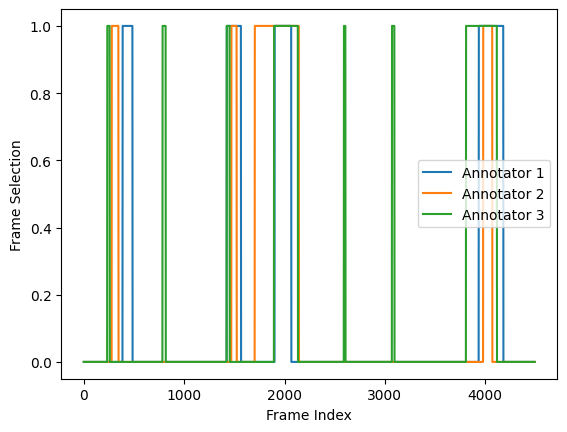

In [7]:
plt.plot(user_annotations[0],label='Annotator 1')
plt.plot(user_annotations[1],label='Annotator 2')
plt.plot(user_annotations[2],label='Annotator 3')
plt.legend()
plt.xlabel('Frame Index')
plt.ylabel('Frame Selection')

Since SumMe annotators selects shots, the question is how the ground truths are constructed/models are evaluated.
There are a few approaches. But by far the most common one is by averaging the ground truth per annotator

Text(0, 0.5, '"Importance Scores"')

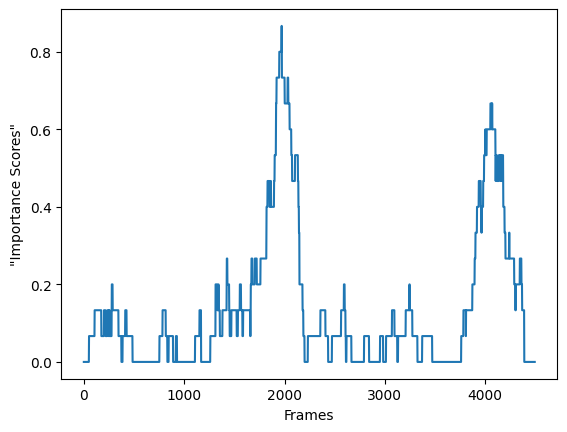

In [8]:
summe_gt = user_annotations.mean(0)

plt.plot(summe_gt)
plt.xlabel('Frames')
plt.ylabel('"Importance Scores"')

TVSum is a bit different, as mentioned previously the annotators rated 2 second segments of the video between 1 to 5. So the annotations look a bit more along these lines

In [5]:
user_annotations = tvsum[0]['user_anno'].T

In [16]:
np.__version__

'1.24.4'

In [ ]:
np.unique(user_annotations[8],return_counts=True)

(array([1., 2., 3., 4., 5.]),
 array([4544, 2399, 1976, 1079,  599], dtype=int64))

In [1]:
rated_values = np.unique(user_annotations[8],return_counts=True)
print(f'Percentage of the video rated highly:')
print((rated_values[1][3]+rated_values[1][4])/np.mean(rated_values[1]))

NameError: name 'np' is not defined

Text(0, 0.5, 'Rated Relevance Score')

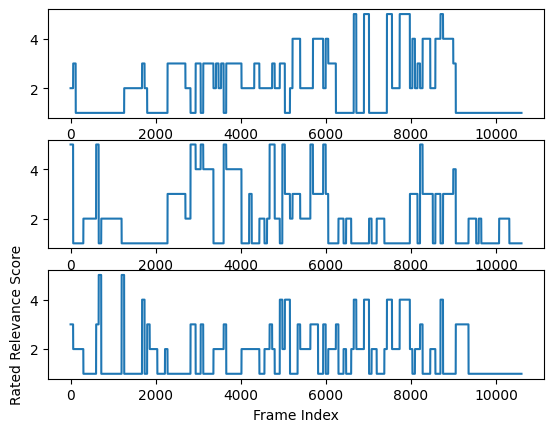

In [13]:
fig,ax = plt.subplots(3)
ax[0].plot(user_annotations[8])
ax[1].plot(user_annotations[9])
ax[2].plot(user_annotations[10])
plt.xlabel('Frame Index')
plt.ylabel('Rated Relevance Score')


Typically, the annotator labels are averaged over and then model predictions are 

Text(0, 0.5, "Average 'Importance'")

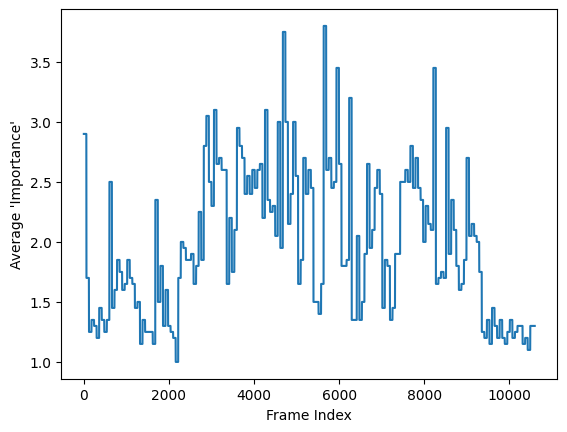

In [8]:
plt.plot(np.mean(user_annotations,axis=0))
plt.xlabel('Frame Index')
plt.ylabel("Average 'Importance'")

# The challenges in Video Summarization

While the initial steps seem to make sense, there are several open questions that still remain:

1. How are video Summarization models evaluated?
2. How do we actually produce the video summary?
3. How do we optimize machine learning models to predict saliency scores for video summarization? 

The answer to these questions are at the crux of why I am making this repository in the first place. The practice of evaluating video summarization is weird and complex, with some of the steps being a bit illogical. 

Answering the question in reverse chronological order, 

A.3: The models are optimimzed by matching these average scores (in some cases, they do use all annotations for evaluation, but it isn't evident whether this is actually helpful)
```text
+----------------------+     +----------------------+     +---------------------------+     +---------------------------+
|                      |     |                      |     |   Model training          |     |                           |
|   User Annotation    | --> |      Pre-Processing  | --> |          and              | --> |      Model Prediction     |
|                      |     |      Aggregation     |     |       Evaluation          |     |                           |
+----------------------+     +----------------------+     +---------------------------+     +---------------------------+
```


A.2: We produce the video summary by post processing the video, visualized as follows:

```text
+----------------------+     +----------------------+     +---------------------------+     +---------------------------+
|                      |     |                      |     |   Score Averaging &       |     |                           |
|   Model Prediction   | --> |      Up Sample       | --> |   Shot Selection          | --> |      Cut and Stitch       |
|                      |     |                      |     | (Knapsack Algorithm, Top K)|    |       Final Summary       |
+----------------------+     +----------------------+     +---------------------------+     +---------------------------+
```

A.1: This answer remains as the primary motivation behind this repository. The literature evaluates the literature very differently, which causes some major problems.

Previously, Video Summarisation used to evaluate the model predictions by comparing the Final Summary with the User annotations:
1. In the case of SumMe type dataset: The model predictions are directly compared the user annotations, since they are selected Segments
2. In the case of TVSum type datasets: The model predictions are compared to the post-processed versions of the original user ratings

However, this evaluation is deeply flawed, as Otani et al demonstrated that the the shot boundary detection algorithm heavily biased the results, and the use of such an approach obfuscates true model performance. 

While newer approaches use Spearman/Kendall Correlation efficient, directly comparing Model Predictions before processing, but a few other issues arise in the literature, providing the impetus as to why I am making this repository in the first place. This step is completely inconsistent across the literature.

1. Some cases TVSum type datasets are evaluated by comparing the model predictions with each of the annotators individually, but SumMe is evaluated using the averaged user annotators.
2. In some cases, model predictions are directly compared with the User annotations (the 0/1 annotations, see the earlier cells)
3. In some cases, model predictions are post-processed to create a user summary, and then are correlated with the user summaries (potentially re-introducing existing biases due to the shot boundaries)
4. Or otherwise a mix of all of the above. However, none of which are specified in the paper, but is evident within the repository. 

In addition to these issues, there are a host of other problems:
1. What contributes to high correlation? Model Architecture or Feature Representations?
2. Does model performance generalise between datasets?
3. How much does modality choice matter?


# What can we do? 

1. Consolidate the literature and compare different evaluation strategies:
    1. Do features influence the model results more than the model? 
    2. How does model performance vary between datasets? 
    3. Do model predictions generalize between datasets? 
    4. (already done) are different parts of pipeline reproducible 

2. Think about the way we conducting a large-scale reproducbility study
    1. Implementing different models
    2. Adding pytests 
    3. Implementing evaluation strategies 
    4. Comparing results versus random 
    5. Implement an automatic:
        1. Select model of choice
        2. Select shot boundaries of choice;
        3. Summary generation 
3. What is already there: 
    1. Different evaluation strategies:
    2. Models implemented 
    3. Scripts to create and cut video
    4. Visual Feature extraction script
4. What needs to be done:
    1. Implementing a few more models
    2. Adding pytests:
        1. Evaluation
        2. Model verficiation 
        3. Feature extraction
    3. Data processing:
        1. Uni-modal
        2. Multi-modal
    4. Feature extraction:
        1. Visual Features: Motion
        2. Textual features:
            Manual or automatic captions
        3. Generating automatic captions per time/aligned with the video
        4. Extracting audio features. (NO CLUE)
    5. Add lightning to make things convenient. 
    6. Find dataset videos in some cases
    7. Adding shot detection

In [ ]:
#